# Parametric PennyLane QAOA processor

This notebook reads the **Assets** sheet directly.

Core behavior:

- **Each asset row is one binary decision variable / one qubit**
- repeated tickers are allowed, so different assets can have different numbers of selectable options
- **no extra same-asset block constraint**
- QUBO uses:
  - return reward
  - risk penalty
  - quadratic budget penalty
- solver behavior is controlled from the **Settings** sheet

Important:

- The notebook can auto-skip QAOA when the option count is above the configured safety threshold.
- Classical search can be switched off from Excel.
- If `refresh_market_data = 1`, market inputs are refreshed per unique ticker.  
  If `Shares` is filled on an option row, `Approx Cost USD` is recomputed from `Shares × Current Price`.

Output sheets:

- `Results_Summary`
- `Results_Overview`
- `Results_Portfolios`
- `Solver_Comparison`
- `Classical_Candidates`
- `QAOA_Samples`
- `Optimization_History`

In [1]:
# !pip -q install yfinance openpyxl pandas numpy scipy matplotlib pennylane pennylane-lightning

In [2]:
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill
from scipy.optimize import minimize

try:
    import yfinance as yf
except Exception:
    yf = None

try:
    import pennylane as qml
except Exception:
    qml = None

In [3]:
xlsx_path = Path("parametric_assets_only_input.xlsx")

# Optional manual override for quick ad-hoc testing.
REFRESH_OVERRIDE = None
xlsx_path

PosixPath('parametric_assets_only_input.xlsx')

In [4]:
def setting_value(settings, key, default=None):
    return settings[key] if key in settings and pd.notna(settings[key]) else default

def setting_bool(settings, key, default=False):
    val = setting_value(settings, key, default)
    if isinstance(val, str):
        val = val.strip().lower()
        if val in {"1", "true", "yes", "y", "on"}:
            return True
        if val in {"0", "false", "no", "n", "off"}:
            return False
    try:
        return bool(int(val))
    except Exception:
        return bool(val)

def setting_int(settings, key, default=0):
    val = setting_value(settings, key, default)
    try:
        return int(float(val))
    except Exception:
        return int(default)

def setting_float(settings, key, default=0.0):
    val = setting_value(settings, key, default)
    try:
        return float(val)
    except Exception:
        return float(default)

xls = pd.ExcelFile(xlsx_path)

assets_df = pd.read_excel(xls, sheet_name="Assets", header=1)
settings_df = pd.read_excel(xls, sheet_name="Settings", header=1)
settings = dict(zip(settings_df["Key"], settings_df["Value"]))

display(assets_df.head())
display(settings_df)

,decision_id,Ticker,Company,Asset Group,Option Label,Shares,Approx Cost USD,Expected Return Proxy,Annual Volatility,Current Price (USD),Mean Daily Return,Std Daily Return,Allowed,Price Source Status,Source URL
0,NVDA_opt1,NVDA,NVIDIA,NVDA,100k,504,99968.403076,0.954841,0.341148,198.350006,0.002925,0.021490,1,Imported via yfinance,https://pypi.org/project/yfinance/
1,NVDA_opt2,NVDA,NVIDIA,NVDA,150k,756,149952.604614,0.954841,0.341148,198.350006,0.002925,0.021490,1,Imported via yfinance,https://pypi.org/project/yfinance/
2,AAPL_opt1,AAPL,Apple,AAPL,100k,380,100091.997681,0.343020,0.235278,263.399994,0.001294,0.014821,1,Imported via yfinance,https://pypi.org/project/yfinance/
3,AAPL_opt2,AAPL,Apple,AAPL,150k,569,149874.596527,0.343020,0.235278,263.399994,0.001294,0.014821,1,Imported via yfinance,https://pypi.org/project/yfinance/
4,MSFT_opt1,MSFT,Microsoft,MSFT,100k,238,100021.882324,0.151442,0.245407,420.260010,0.000686,0.015459,1,Imported via yfinance,https://pypi.org/project/yfinance/


,Key,Value,Description
0,budget_usd,1000000.00,Target total budget
1,risk_free_rate_annual,0.04,Annual risk-free rate used in excess-return re...
2,lambda_budget,50.00,Budget deviation penalty
3,lambda_variance,6.00,Variance contribution weight
4,lambda_exclusive,0.00,Unused in current notebook; kept for transparency
5,top_n_export,20.00,Number of candidate portfolios exported to ove...
6,refresh_market_data,0.00,1 = refresh prices/returns/volatility from yfi...
7,enable_qaoa,1.00,"1 = run QAOA, 0 = skip QAOA"
8,qaoa_p,1.00,QAOA depth / number of layers
9,qaoa_maxiter,60.00,Optimizer iteration budget for QAOA


In [5]:
REFRESH_WITH_YFINANCE = setting_bool(settings, "refresh_market_data", False)
if REFRESH_OVERRIDE is not None:
    REFRESH_WITH_YFINANCE = bool(REFRESH_OVERRIDE)

TOP_N_EXPORT = setting_int(settings, "top_n_export", 20)
ENABLE_QAOA = setting_bool(settings, "enable_qaoa", True)
QAOA_P = setting_int(settings, "qaoa_p", 1)
QAOA_MAXITER = setting_int(settings, "qaoa_maxiter", 60)
QAOA_SHOTS = setting_int(settings, "qaoa_shots", 4096)
QAOA_EXACT_PROBABILITY_MAX_QUBITS = setting_int(settings, "qaoa_exact_probability_max_qubits", 24)
QAOA_MAX_QUBITS_ALLOWED = setting_int(settings, "qaoa_max_qubits_allowed", 24)

ENABLE_CLASSICAL_SEARCH = setting_bool(settings, "enable_classical_search", True)
RANDOM_SEARCH_SAMPLES = setting_int(settings, "classical_random_search_samples", 8000)
LOCAL_SEARCH_STARTS = setting_int(settings, "classical_local_search_starts", 40)
CLASSICAL_MAX_NEIGHBOR_EVALS = setting_int(settings, "classical_max_neighbor_evals", 200000)

OVERVIEW_CLASSICAL_POOL = setting_int(settings, "overview_classical_pool", 300)
OVERVIEW_QAOA_POOL = setting_int(settings, "overview_qaoa_pool", 500)
RESULT_CANDIDATE_LIMIT_PER_SOLVER = setting_int(settings, "result_candidate_limit_per_solver", 500)
RNG_SEED = setting_int(settings, "rng_seed", 42)

random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

budget_usd = setting_float(settings, "budget_usd", 1_000_000.0)
risk_free = setting_float(settings, "risk_free_rate_annual", 0.04)
lambda_budget = setting_float(settings, "lambda_budget", 50.0)
lambda_variance = setting_float(settings, "lambda_variance", 6.0)
lambda_exclusive = 0.0

print("Refresh with yfinance:", REFRESH_WITH_YFINANCE)
print("Enable QAOA:", ENABLE_QAOA)
print("Enable classical search:", ENABLE_CLASSICAL_SEARCH)

Refresh with yfinance: False
Enable QAOA: True
Enable classical search: True


In [6]:
if REFRESH_WITH_YFINANCE:
    if yf is None:
        raise ImportError("yfinance is required when refresh_market_data = 1.")
    option_rows = assets_df.loc[assets_df["Ticker"].notna()].copy()
    if "Allowed" in option_rows.columns:
        option_rows = option_rows.loc[option_rows["Allowed"].fillna(1).astype(int) == 1].copy()

    tickers = list(dict.fromkeys(option_rows["Ticker"].astype(str).tolist()))
    if len(tickers) == 0:
        raise ValueError("No tickers available to refresh.")

    prices = yf.download(
        tickers=tickers,
        period="12mo",
        interval="1d",
        auto_adjust=True,
        progress=False,
    )["Close"]

    if isinstance(prices, pd.Series):
        prices = prices.to_frame()

    prices = prices.dropna(how="all").ffill().dropna()
    rets = prices.pct_change().dropna()

    total_return_12m = prices.iloc[-1] / prices.iloc[0] - 1
    ann_vol = rets.std() * np.sqrt(252)
    mean_daily = rets.mean()
    std_daily = rets.std()
    daily_cov = rets.cov()
    annual_cov = daily_cov * 252
    latest_price = prices.iloc[-1]

    wb = load_workbook(xlsx_path)
    sh_assets = wb["Assets"]
    sh_returns = wb["Returns"]
    sh_cov = wb["Covariance"]
    sh_acov = wb["AnnualizedCovariance"]
    sh_ph = wb["PriceHistory"]

    asset_headers = [sh_assets.cell(2, c).value for c in range(1, sh_assets.max_column + 1)]
    col_idx = {h: i + 1 for i, h in enumerate(asset_headers)}

    # Clear and rewrite price history
    for row in sh_ph.iter_rows(min_row=3, max_row=max(sh_ph.max_row, 5000), min_col=1, max_col=1 + len(tickers)):
        for cell in row:
            cell.value = None

    for r_idx, dt in enumerate(prices.index, start=3):
        sh_ph.cell(r_idx, 1, dt.to_pydatetime())
        for c_idx, t in enumerate(tickers, start=2):
            sh_ph.cell(r_idx, c_idx, float(prices.loc[dt, t]))

    # Update per-option rows in Assets
    for r_idx in range(3, sh_assets.max_row + 1):
        ticker = sh_assets.cell(r_idx, col_idx["Ticker"]).value
        if not ticker or ticker not in latest_price.index:
            continue

        sh_assets.cell(r_idx, col_idx["Current Price (USD)"], float(latest_price[ticker]))
        sh_assets.cell(r_idx, col_idx["Expected Return Proxy"], float(total_return_12m[ticker]))
        sh_assets.cell(r_idx, col_idx["Annual Volatility"], float(ann_vol[ticker]))

        if "Mean Daily Return" in col_idx:
            sh_assets.cell(r_idx, col_idx["Mean Daily Return"], float(mean_daily[ticker]))
        if "Std Daily Return" in col_idx:
            sh_assets.cell(r_idx, col_idx["Std Daily Return"], float(std_daily[ticker]))
        if "Price Source Status" in col_idx:
            sh_assets.cell(r_idx, col_idx["Price Source Status"], "Refreshed with yfinance")
        if "Source URL" in col_idx:
            sh_assets.cell(r_idx, col_idx["Source URL"], "https://pypi.org/project/yfinance/")

        # If Shares is present, refresh Approx Cost USD from Shares × Current Price.
        if "Shares" in col_idx and "Approx Cost USD" in col_idx:
            shares = sh_assets.cell(r_idx, col_idx["Shares"]).value
            try:
                if shares is not None and not pd.isna(shares):
                    sh_assets.cell(r_idx, col_idx["Approx Cost USD"], float(shares) * float(latest_price[ticker]))
            except Exception:
                pass

    # Update per-ticker returns sheet
    for row in sh_returns.iter_rows(min_row=3, max_row=max(sh_returns.max_row, 5000), min_col=1, max_col=6):
        for cell in row:
            cell.value = None

    for idx, ticker in enumerate(tickers, start=3):
        sh_returns.cell(idx, 1, ticker)
        sh_returns.cell(idx, 2, float(total_return_12m[ticker]))
        sh_returns.cell(idx, 3, float(ann_vol[ticker]))
        sh_returns.cell(idx, 4, float(mean_daily[ticker]))
        sh_returns.cell(idx, 5, float(std_daily[ticker]))
        sh_returns.cell(idx, 6, "Refreshed with yfinance")

    # Update covariance matrices
    for i, tr in enumerate(tickers, start=3):
        sh_cov.cell(i, 1, tr)
        sh_acov.cell(i, 1, tr)
        for j, tc in enumerate(tickers, start=2):
            sh_cov.cell(2, j, tc)
            sh_acov.cell(2, j, tc)
            sh_cov.cell(i, j, float(daily_cov.loc[tr, tc]))
            sh_acov.cell(i, j, float(annual_cov.loc[tr, tc]))

    wb.save(xlsx_path)

    # Reload
    xls = pd.ExcelFile(xlsx_path)
    assets_df = pd.read_excel(xls, sheet_name="Assets", header=1)
    settings_df = pd.read_excel(xls, sheet_name="Settings", header=1)
    settings = dict(zip(settings_df["Key"], settings_df["Value"]))

    print(f"Workbook refreshed and saved to {xlsx_path.resolve()}")

In [7]:
blocks_df = assets_df.loc[assets_df["Ticker"].notna()].copy()
blocks_df["Ticker"] = blocks_df["Ticker"].astype(str)

if "Allowed" in blocks_df.columns:
    blocks_df = blocks_df.loc[blocks_df["Allowed"].fillna(1).astype(int) == 1].copy()

required_option_cols = ["Ticker", "Approx Cost USD", "Expected Return Proxy", "Annual Volatility"]
missing_option_cols = [c for c in required_option_cols if c not in blocks_df.columns]
if missing_option_cols:
    raise ValueError(
        "Assets sheet must define the selectable options directly. "
        f"Missing required columns: {missing_option_cols}"
    )

for col in ["Approx Cost USD", "Expected Return Proxy", "Annual Volatility"]:
    blocks_df[col] = pd.to_numeric(blocks_df[col], errors="coerce")

if blocks_df["Approx Cost USD"].isna().any():
    bad = blocks_df.loc[blocks_df["Approx Cost USD"].isna(), "Ticker"].tolist()
    raise ValueError(f"Approx Cost USD missing for options: {bad}")

if (blocks_df["Approx Cost USD"] <= 0).any():
    bad = blocks_df.loc[blocks_df["Approx Cost USD"] <= 0, ["Ticker", "Approx Cost USD"]]
    raise ValueError(f"Approx Cost USD must be > 0 for all options. Bad rows:\n{bad}")

if "decision_id" not in blocks_df.columns:
    blocks_df["decision_id"] = [f"{ticker}_opt{i+1}" for i, ticker in enumerate(blocks_df["Ticker"].tolist())]
else:
    blocks_df["decision_id"] = blocks_df["decision_id"].astype(str)

if "Company" not in blocks_df.columns:
    blocks_df["Company"] = blocks_df["Ticker"]

if "Option Label" not in blocks_df.columns:
    blocks_df["Option Label"] = ""

if "Shares" not in blocks_df.columns:
    blocks_df["Shares"] = np.nan

if "Asset Group" not in blocks_df.columns:
    blocks_df["Asset Group"] = blocks_df["Ticker"]

blocks_df = blocks_df.reset_index(drop=True)

annual_cov_df = pd.read_excel(xls, sheet_name="AnnualizedCovariance", header=1)
annual_cov_df = annual_cov_df.rename(columns={annual_cov_df.columns[0]: "Ticker"})
annual_cov_df = annual_cov_df.loc[annual_cov_df["Ticker"].notna()].copy()
annual_cov_df["Ticker"] = annual_cov_df["Ticker"].astype(str)
annual_cov_df = annual_cov_df.set_index("Ticker")

asset_universe = list(dict.fromkeys(blocks_df["Ticker"].tolist()))
missing_cov_assets = [t for t in asset_universe if t not in annual_cov_df.index or t not in annual_cov_df.columns]
if missing_cov_assets:
    raise ValueError(
        "AnnualizedCovariance sheet is missing these tickers used by the options: "
        + ", ".join(missing_cov_assets)
    )

Sigma_assets = annual_cov_df.loc[asset_universe, asset_universe].to_numpy(dtype=float)
ticker_to_idx = {t: i for i, t in enumerate(asset_universe)}

decision_ids = blocks_df["decision_id"].tolist()
opt_tickers = blocks_df["Ticker"].tolist()
opt_cost = blocks_df["Approx Cost USD"].astype(float).to_numpy()
opt_ret = blocks_df["Expected Return Proxy"].astype(float).to_numpy()
option_asset_groups = blocks_df["Asset Group"].astype(str).tolist()

n = len(blocks_df)
Sigma_opt = np.zeros((n, n), dtype=float)
for i in range(n):
    ai = ticker_to_idx[opt_tickers[i]]
    for j in range(n):
        aj = ticker_to_idx[opt_tickers[j]]
        Sigma_opt[i, j] = Sigma_assets[ai, aj]

if ENABLE_QAOA and n > QAOA_MAX_QUBITS_ALLOWED:
    print(
        f"QAOA auto-disabled: n={n} exceeds qaoa_max_qubits_allowed={QAOA_MAX_QUBITS_ALLOWED}. "
        "You can raise the threshold in Settings, but statevector simulation may become infeasible."
    )
    ENABLE_QAOA = False

print(f"Assets referenced by options: {len(asset_universe)}")
print(f"Decision variables from Excel: {n}")
print(f"QAOA layers p: {QAOA_P}")
display(blocks_df.head(10))

Assets referenced by options: 12
Decision variables from Excel: 24
QAOA layers p: 1


,decision_id,Ticker,Company,Asset Group,Option Label,Shares,Approx Cost USD,Expected Return Proxy,Annual Volatility,Current Price (USD),Mean Daily Return,Std Daily Return,Allowed,Price Source Status,Source URL
0,NVDA_opt1,NVDA,NVIDIA,NVDA,100k,504,99968.403076,0.954841,0.341148,198.350006,0.002925,0.021490,1,Imported via yfinance,https://pypi.org/project/yfinance/
1,NVDA_opt2,NVDA,NVIDIA,NVDA,150k,756,149952.604614,0.954841,0.341148,198.350006,0.002925,0.021490,1,Imported via yfinance,https://pypi.org/project/yfinance/
2,AAPL_opt1,AAPL,Apple,AAPL,100k,380,100091.997681,0.343020,0.235278,263.399994,0.001294,0.014821,1,Imported via yfinance,https://pypi.org/project/yfinance/
3,AAPL_opt2,AAPL,Apple,AAPL,150k,569,149874.596527,0.343020,0.235278,263.399994,0.001294,0.014821,1,Imported via yfinance,https://pypi.org/project/yfinance/
4,MSFT_opt1,MSFT,Microsoft,MSFT,100k,238,100021.882324,0.151442,0.245407,420.260010,0.000686,0.015459,1,Imported via yfinance,https://pypi.org/project/yfinance/
5,MSFT_opt2,MSFT,Microsoft,MSFT,150k,357,150032.823486,0.151442,0.245407,420.260010,0.000686,0.015459,1,Imported via yfinance,https://pypi.org/project/yfinance/
6,AVGO_opt1,AVGO,Broadcom,AVGO,100k,251,100015.970306,1.349252,0.428005,398.470001,0.003795,0.026962,1,Imported via yfinance,https://pypi.org/project/yfinance/
7,AVGO_opt2,AVGO,Broadcom,AVGO,150k,376,149824.720459,1.349252,0.428005,398.470001,0.003795,0.026962,1,Imported via yfinance,https://pypi.org/project/yfinance/
8,MU_opt1,MU,Micron Technology,MU,100k,219,100133.372406,5.661693,0.590771,457.230011,0.008330,0.037215,1,Imported via yfinance,https://pypi.org/project/yfinance/
9,MU_opt2,MU,Micron Technology,MU,150k,328,149971.443604,5.661693,0.590771,457.230011,0.008330,0.037215,1,Imported via yfinance,https://pypi.org/project/yfinance/


In [8]:
def build_qubo_budget_first(opt_ret, risk_free, opt_cost, Sigma_opt, budget_usd,
                             lambda_budget, lambda_variance, lambda_exclusive, opt_tickers):
    n = len(opt_ret)
    Q = np.zeros((n, n), dtype=float)

    scaled_cost = opt_cost / float(budget_usd)

    ret_excess = opt_ret - risk_free
    ret_scale = np.max(np.abs(ret_excess)) + 1e-12
    ret_scaled = ret_excess / ret_scale

    sigma_scale = np.max(np.abs(Sigma_opt)) + 1e-12
    Sigma_scaled = Sigma_opt / sigma_scale

    reward = ret_scaled * scaled_cost
    for i in range(n):
        Q[i, i] += -reward[i]

    for i in range(n):
        Q[i, i] += lambda_variance * (scaled_cost[i] ** 2) * Sigma_scaled[i, i]
    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] += 2.0 * lambda_variance * scaled_cost[i] * scaled_cost[j] * Sigma_scaled[i, j]

    for i in range(n):
        Q[i, i] += lambda_budget * (scaled_cost[i] ** 2 - 2.0 * scaled_cost[i])
    for i in range(n):
        for j in range(i + 1, n):
            Q[i, j] += 2.0 * lambda_budget * scaled_cost[i] * scaled_cost[j]
    constant = float(lambda_budget)

    lambda_exclusive_effective = 0.0

    qubo_meta = {
        "scaled_cost": scaled_cost,
        "ret_scaled": ret_scaled,
        "Sigma_scaled": Sigma_scaled,
        "lambda_budget": float(lambda_budget),
        "lambda_variance": float(lambda_variance),
        "lambda_exclusive": float(lambda_exclusive_effective),
        "opt_tickers": list(opt_tickers),
        "budget_usd": float(budget_usd),
        "ret_scale": float(ret_scale),
        "sigma_scale": float(sigma_scale),
    }

    return Q, constant, qubo_meta

Q, constant, qubo_meta = build_qubo_budget_first(
    opt_ret, risk_free, opt_cost, Sigma_opt, budget_usd,
    lambda_budget, lambda_variance, lambda_exclusive, opt_tickers
)

pd.DataFrame(Q, index=decision_ids, columns=decision_ids).iloc[:10, :10]

,NVDA_opt1,NVDA_opt2,AAPL_opt1,AAPL_opt2,MSFT_opt1,MSFT_opt2,AVGO_opt1,AVGO_opt2,MU_opt1,MU_opt2
NVDA_opt1,-9.496313,1.550385,1.007524,1.508635,1.010219,1.515328,1.025473,1.536167,1.029845,1.542416
NVDA_opt2,0.000000,-13.856874,1.511287,2.262953,1.515328,2.272993,1.538209,2.304250,1.544767,2.313623
AAPL_opt1,0.000000,0.000000,-9.505516,1.524558,1.004048,1.506073,1.008228,1.510334,1.009671,1.512201
AAPL_opt2,0.000000,0.000000,0.000000,-13.854125,1.503430,2.255146,1.509689,2.261527,1.511849,2.264322
MSFT_opt1,0.000000,0.000000,0.000000,0.000000,-9.495088,1.527248,1.011087,1.514617,1.008991,1.511183
MSFT_opt2,0.000000,0.000000,0.000000,0.000000,0.000000,-13.860820,1.516631,2.271925,1.513486,2.266774
AVGO_opt1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.497772,1.579255,1.034838,1.549894
AVGO_opt2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-13.834497,1.550196,2.321754
MU_opt1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.560653,1.655927
MU_opt2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-13.907061


In [9]:
def qubo_value(bitvec, Q, constant=0.0):
    x = np.asarray(bitvec, dtype=float)
    return float(x @ Q @ x + constant)

def qubo_term_breakdown(bitvec, qubo_meta):
    x = np.asarray(bitvec, dtype=float)

    scaled_cost = np.asarray(qubo_meta["scaled_cost"], dtype=float)
    ret_scaled = np.asarray(qubo_meta["ret_scaled"], dtype=float)
    Sigma_scaled = np.asarray(qubo_meta["Sigma_scaled"], dtype=float)
    lambda_budget = float(qubo_meta["lambda_budget"])
    lambda_variance = float(qubo_meta["lambda_variance"])

    num_selected = int(x.sum())

    return_term = float(-np.dot(ret_scaled * scaled_cost, x))
    weighted = x * scaled_cost
    risk_term = float(lambda_variance * (weighted @ Sigma_scaled @ weighted))
    budget_term = float(lambda_budget * (weighted.sum() - 1.0) ** 2)
    exclusivity_term = 0.0

    total = float(return_term + risk_term + budget_term + exclusivity_term)

    denom = max(num_selected, 1)
    return {
        "return_term": return_term,
        "risk_term": risk_term,
        "budget_term": budget_term,
        "exclusivity_term": exclusivity_term,
        "qubo_reconstructed": total,
        "avg_return_term_per_option": float(return_term / denom),
        "avg_risk_term_per_option": float(risk_term / denom),
        "avg_budget_term_per_option": float(budget_term / denom),
        "avg_exclusivity_term_per_option": 0.0,
    }

def portfolio_stats(bitvec, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd):
    x = np.asarray(bitvec, dtype=float)
    selected_cost = x * opt_cost
    total = float(selected_cost.sum())
    num_selected = int(x.sum())

    if total <= 0:
        return {
            "selected_usd": 0.0,
            "budget_gap": -budget_usd,
            "abs_budget_gap": abs(-budget_usd),
            "num_options": 0,
            "num_distinct_assets": 0,
            "portfolio_return": 0.0,
            "portfolio_vol": 0.0,
            "sharpe_like": np.nan,
            "max_position_usd": 0.0,
        }

    weights = selected_cost / total
    port_ret = float(np.dot(weights, opt_ret))
    port_var = float(weights @ Sigma_opt @ weights)
    port_vol = float(np.sqrt(max(port_var, 0.0)))
    sharpe = np.nan if port_vol == 0 else (port_ret - risk_free) / port_vol
    distinct_assets = len(set([opt_tickers[i] for i, b in enumerate(x) if b > 0.5]))
    max_position = float(selected_cost.max())
    budget_gap = total - budget_usd

    return {
        "selected_usd": total,
        "budget_gap": budget_gap,
        "abs_budget_gap": abs(budget_gap),
        "num_options": num_selected,
        "num_distinct_assets": distinct_assets,
        "portfolio_return": port_ret,
        "portfolio_vol": port_vol,
        "sharpe_like": sharpe,
        "max_position_usd": max_position,
    }

def exploded_portfolio_rows(rank, source, bitstring, bitvec, blocks_df, Q, constant, qubo_meta, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd):
    term_stats = qubo_term_breakdown(bitvec, qubo_meta)
    stats = portfolio_stats(bitvec, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
    rows = []
    for idx, flag in enumerate(bitvec):
        if flag != 1:
            continue
        row = {
            "rank": rank,
            "source": source,
            "bitstring": bitstring,
            "Ticker": blocks_df.loc[idx, "Ticker"],
            "Company": blocks_df.loc[idx, "Company"] if "Company" in blocks_df.columns else blocks_df.loc[idx, "Ticker"],
            "Option Label": blocks_df.loc[idx, "Option Label"] if "Option Label" in blocks_df.columns else "",
            "Shares": blocks_df.loc[idx, "Shares"] if "Shares" in blocks_df.columns else np.nan,
            "Approx Cost USD": float(blocks_df.loc[idx, "Approx Cost USD"]),
            "Expected Return Proxy": float(blocks_df.loc[idx, "Expected Return Proxy"]),
            "Annual Volatility": float(blocks_df.loc[idx, "Annual Volatility"]),
            "decision_id": blocks_df.loc[idx, "decision_id"],
            **term_stats,
            **stats,
            "qubo_value": qubo_value(bitvec, Q, constant),
        }
        rows.append(row)
    return rows

In [10]:
def sort_candidates(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame()

    df = df.copy()

    sort_cols = []
    ascending = []

    if "qubo_value" in df.columns:
        sort_cols.append("qubo_value")
        ascending.append(True)

    if "abs_budget_gap" in df.columns:
        sort_cols.append("abs_budget_gap")
        ascending.append(True)

    if "portfolio_return" in df.columns:
        sort_cols.append("portfolio_return")
        ascending.append(False)

    if "bitstring" in df.columns:
        sort_cols.append("bitstring")
        ascending.append(True)

    return df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)

def random_solution(n):
    return np.random.randint(0, 2, size=n, dtype=int)

def greedy_improve_unconstrained(x, Q, constant, max_neighbor_evals=200000):
    x = x.copy()
    improved = True
    neighbor_evals = 0
    while improved and neighbor_evals < max_neighbor_evals:
        improved = False
        current_val = qubo_value(x, Q, constant)
        for i in range(len(x)):
            if neighbor_evals >= max_neighbor_evals:
                break
            y = x.copy()
            y[i] = 1 - y[i]
            y_val = qubo_value(y, Q, constant)
            neighbor_evals += 1
            if y_val < current_val - 1e-9:
                x = y
                current_val = y_val
                improved = True
    return x

candidate_cols = [
    "bitstring", "source", "probability", "qubo_value",
    "return_term", "risk_term", "budget_term", "exclusivity_term", "qubo_reconstructed",
    "avg_return_term_per_option", "avg_risk_term_per_option", "avg_budget_term_per_option", "avg_exclusivity_term_per_option",
    "selected_usd", "budget_gap", "abs_budget_gap", "num_options", "num_distinct_assets",
    "portfolio_return", "portfolio_vol", "sharpe_like", "max_position_usd"
]

if ENABLE_CLASSICAL_SEARCH:
    candidate_dict = {}
    for _ in range(max(RANDOM_SEARCH_SAMPLES, 0)):
        x = random_solution(n)
        x = greedy_improve_unconstrained(x, Q, constant, CLASSICAL_MAX_NEIGHBOR_EVALS)
        bitstring = "".join(map(str, x.astype(int)))
        stats = portfolio_stats(x, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
        term_stats = qubo_term_breakdown(x, qubo_meta)
        candidate_dict[bitstring] = {
            "bitstring": bitstring,
            "source": "classical_heuristic",
            "probability": np.nan,
            "qubo_value": qubo_value(x, Q, constant),
            **term_stats,
            **stats
        }

    for start_idx in range(min(n, max(LOCAL_SEARCH_STARTS, 0))):
        x = np.zeros(n, dtype=int)
        x[start_idx] = 1
        x = greedy_improve_unconstrained(x, Q, constant, CLASSICAL_MAX_NEIGHBOR_EVALS)
        bitstring = "".join(map(str, x.astype(int)))
        stats = portfolio_stats(x, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
        term_stats = qubo_term_breakdown(x, qubo_meta)
        candidate_dict[bitstring] = {
            "bitstring": bitstring,
            "source": "classical_heuristic",
            "probability": np.nan,
            "qubo_value": qubo_value(x, Q, constant),
            **term_stats,
            **stats
        }

    classical_results = sort_candidates(pd.DataFrame(candidate_dict.values()))
else:
    classical_results = pd.DataFrame(columns=candidate_cols)

display(classical_results.head(20))
print("Classical candidate count:", len(classical_results))

,bitstring,source,probability,qubo_value,return_term,risk_term,budget_term,exclusivity_term,qubo_reconstructed,avg_return_term_per_option,...,avg_exclusivity_term_per_option,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,111111100000000000010000,classical_heuristic,NaN,0.477876,-0.096009,0.573885,1.470012e-07,0.0,0.477876,-0.012001,...,0.0,9.999458e+05,-54.221985,54.221985,8,5,0.579764,0.197517,2.732750,150032.823486
1,010111100000100000011000,classical_heuristic,NaN,0.558807,-0.144722,0.703521,8.196423e-06,0.0,0.558807,-0.018090,...,0.0,9.995951e+05,-404.880798,404.880798,8,7,0.853912,0.218767,3.720447,150032.823486
2,001110011100000000110000,classical_heuristic,NaN,0.564460,-0.323143,0.887602,8.578797e-07,0.0,0.564460,-0.040393,...,0.0,9.998690e+05,-130.987000,130.987000,8,5,1.856851,0.245660,7.395802,149987.500000
3,111111100000000000100000,classical_heuristic,NaN,0.570025,-0.091468,0.536102,1.253914e-01,0.0,0.570025,-0.011434,...,0.0,9.499218e+05,-50078.221985,50078.221985,8,5,0.581315,0.200957,2.693682,150032.823486
4,111111100100000000000000,classical_heuristic,NaN,0.571318,-0.232366,0.803684,2.469525e-07,0.0,0.571318,-0.029046,...,0.0,9.999297e+05,-70.278381,70.278381,8,5,1.346381,0.233744,5.588929,150032.823486
5,111110001000000001010000,classical_heuristic,NaN,0.574091,-0.238685,0.812776,1.028612e-07,0.0,0.574091,-0.029836,...,0.0,1.000045e+06,45.356628,45.356628,8,6,1.381755,0.235036,5.708727,150015.000000
6,011101000000101000010010,classical_heuristic,NaN,0.574684,-0.178004,0.752680,8.154383e-06,0.0,0.574684,-0.022251,...,0.0,1.000404e+06,403.841125,403.841125,8,7,1.040282,0.226099,4.424095,150032.823486
7,111111100000000000000100,classical_heuristic,NaN,0.579006,-0.131041,0.710047,2.434322e-07,0.0,0.579006,-0.016380,...,0.0,1.000070e+06,69.775665,69.775665,8,5,0.776623,0.219675,3.353233,150111.497650
8,111101000000000001101000,classical_heuristic,NaN,0.579638,-0.167350,0.746983,4.109162e-06,0.0,0.579638,-0.020919,...,0.0,9.997133e+05,-286.676178,286.676178,8,6,0.981058,0.225397,4.175113,150032.823486
9,111111100000000000000001,classical_heuristic,NaN,0.586718,-0.127916,0.714598,3.566949e-05,0.0,0.586718,-0.015989,...,0.0,9.991554e+05,-844.624084,844.624084,8,5,0.759711,0.220580,3.262816,150032.823486


Classical candidate count: 5668


In [11]:
samples_df = pd.DataFrame(columns=candidate_cols)

history_columns = ["iteration"]
history_columns += [f"gamma_{i+1}" for i in range(QAOA_P)]
history_columns += [f"beta_{i+1}" for i in range(QAOA_P)]
history_columns += ["energy", "best_energy", "elapsed_sec"]
history_df = pd.DataFrame(columns=history_columns)

best_gammas = np.full(QAOA_P, np.nan, dtype=float)
best_betas = np.full(QAOA_P, np.nan, dtype=float)
qaoa_mode = "disabled"

if ENABLE_QAOA:
    def qubo_to_ising(Q, constant=0.0):
        n = Q.shape[0]
        h = np.zeros(n, dtype=float)
        J = {}
        offset = float(constant)
        for i in range(n):
            qii = Q[i, i]
            offset += qii / 2
            h[i] += -qii / 2
        for i in range(n):
            for j in range(i + 1, n):
                qij = Q[i, j]
                if abs(qij) > 1e-12:
                    offset += qij / 4
                    h[i] += -qij / 4
                    h[j] += -qij / 4
                    J[(i, j)] = qij / 4
        return h, J, offset

    h, J, ising_offset = qubo_to_ising(Q, constant)

    coeffs = []
    ops = []
    for i, coeff in enumerate(h):
        if abs(coeff) > 1e-12:
            coeffs.append(float(coeff))
            ops.append(qml.PauliZ(i))
    for (i, j), coeff in J.items():
        if abs(coeff) > 1e-12:
            coeffs.append(float(coeff))
            ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
    if not coeffs:
        coeffs = [0.0]
        ops = [qml.Identity(0)]

    H = qml.Hamiltonian(coeffs, ops)

    exact_mode = n <= QAOA_EXACT_PROBABILITY_MAX_QUBITS
    qaoa_mode = "exact_probs" if exact_mode else f"shots_{QAOA_SHOTS}"
    dev = qml.device("lightning.qubit", wires=n, shots=None if exact_mode else QAOA_SHOTS)

    def apply_qaoa_layer(gamma, beta):
        for i, coeff in enumerate(h):
            if abs(coeff) > 1e-12:
                qml.RZ(2 * gamma * coeff, wires=i)
        for (i, j), coeff in J.items():
            if abs(coeff) > 1e-12:
                qml.CNOT(wires=[i, j])
                qml.RZ(2 * gamma * coeff, wires=j)
                qml.CNOT(wires=[i, j])
        for w in range(n):
            qml.RX(2 * beta, wires=w)

    @qml.qnode(dev, interface="autograd")
    def qaoa_energy(params):
        gammas = params[:QAOA_P]
        betas = params[QAOA_P:]
        for w in range(n):
            qml.Hadamard(wires=w)
        for layer in range(QAOA_P):
            apply_qaoa_layer(gammas[layer], betas[layer])
        return qml.expval(H)

    if exact_mode:
        @qml.qnode(dev, interface="autograd")
        def qaoa_probs(params):
            gammas = params[:QAOA_P]
            betas = params[QAOA_P:]
            for w in range(n):
                qml.Hadamard(wires=w)
            for layer in range(QAOA_P):
                apply_qaoa_layer(gammas[layer], betas[layer])
            return qml.probs(wires=range(n))
    else:
        @qml.qnode(dev, interface="autograd")
        def qaoa_samples(params):
            gammas = params[:QAOA_P]
            betas = params[QAOA_P:]
            for w in range(n):
                qml.Hadamard(wires=w)
            for layer in range(QAOA_P):
                apply_qaoa_layer(gammas[layer], betas[layer])
            return qml.sample(wires=range(n))

    progress_rows = []
    start_time = time.time()

    def objective_logged(x):
        energy = float(qaoa_energy(x))
        elapsed = time.time() - start_time
        current_best = min([energy] + [r["energy"] for r in progress_rows]) if progress_rows else energy

        row = {"iteration": len(progress_rows) + 1}
        for i in range(QAOA_P):
            row[f"gamma_{i+1}"] = float(x[i])
        for i in range(QAOA_P):
            row[f"beta_{i+1}"] = float(x[QAOA_P + i])
        row["energy"] = energy
        row["best_energy"] = current_best
        row["elapsed_sec"] = elapsed
        progress_rows.append(row)

        gamma_str = "  ".join([f"g{i+1}={x[i]: .5f}" for i in range(QAOA_P)])
        beta_str = "  ".join([f"b{i+1}={x[QAOA_P+i]: .5f}" for i in range(QAOA_P)])
        print(
            f"iter={len(progress_rows):>3}  {gamma_str}  {beta_str}  "
            f"energy={energy: .6f}  best={current_best: .6f}  elapsed={elapsed: .1f}s"
        )
        return energy

    gamma_init = np.linspace(0.30, 0.60, QAOA_P)
    beta_init = np.linspace(0.40, 0.20, QAOA_P)
    x0 = np.concatenate([gamma_init, beta_init]).astype(float)

    res = minimize(objective_logged, x0=x0, method="COBYLA", options={"maxiter": QAOA_MAXITER})
    best_gammas = np.array(res.x[:QAOA_P], dtype=float)
    best_betas = np.array(res.x[QAOA_P:], dtype=float)
    history_df = pd.DataFrame(progress_rows)

    q_rows = []
    params_opt = np.concatenate([best_gammas, best_betas])

    if exact_mode:
        probs = np.array(qaoa_probs(params_opt))
        for idx, prob in enumerate(probs):
            if prob <= 0:
                continue
            bitstring = format(idx, f"0{n}b")[::-1]
            bits = np.array(list(map(int, bitstring)), dtype=int)
            stats = portfolio_stats(bits, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
            term_stats = qubo_term_breakdown(bits, qubo_meta)
            q_rows.append({
                "bitstring": "".join(map(str, bits.astype(int))),
                "source": f"qaoa_full_pennylane_p{QAOA_P}",
                "probability": float(prob),
                "qubo_value": qubo_value(bits, Q, constant),
                **term_stats,
                **stats
            })
    else:
        raw_samples = np.asarray(qaoa_samples(params_opt))
        if raw_samples.ndim == 1:
            raw_samples = raw_samples.reshape(1, -1)

        sample_counts = {}
        for sample in raw_samples:
            bits = np.asarray(sample, dtype=int).reshape(-1)
            bitstring = "".join(map(str, bits.astype(int)))
            sample_counts[bitstring] = sample_counts.get(bitstring, 0) + 1

        total_shots = sum(sample_counts.values())
        for bitstring, count in sample_counts.items():
            bits = np.array(list(map(int, bitstring)), dtype=int)
            stats = portfolio_stats(bits, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
            term_stats = qubo_term_breakdown(bits, qubo_meta)
            q_rows.append({
                "bitstring": bitstring,
                "source": f"qaoa_sampled_pennylane_p{QAOA_P}",
                "probability": float(count / total_shots),
                "qubo_value": qubo_value(bits, Q, constant),
                **term_stats,
                **stats
            })

    samples_df = sort_candidates(pd.DataFrame(q_rows))
    print(f"QAOA completed with p={QAOA_P} in mode={qaoa_mode}.")
    display(history_df.head(20))
    display(samples_df.head(20))
else:
    print("QAOA disabled.")

iter=  1  g1= 0.30000  b1= 0.40000  energy= 41.738487  best= 41.738487  elapsed= 18.1s
iter=  2  g1= 1.30000  b1= 0.40000  energy= 11.373657  best= 11.373657  elapsed= 36.0s
iter=  3  g1= 1.30000  b1= 1.40000  energy= 2.478632  best= 2.478632  elapsed= 53.8s
iter=  4  g1= 2.25967  b1= 1.68112  energy= 1.050033  best= 1.050033  elapsed= 71.6s
iter=  5  g1= 2.13507  b1= 2.67333  energy= 14.631571  best= 1.050033  elapsed= 89.3s
iter=  6  g1= 2.44826  b1= 1.21805  energy= 8.862390  best= 1.050033  elapsed= 107.0s
iter=  7  g1= 2.37544  b1= 1.72827  energy= 2.045009  best= 1.050033  elapsed= 124.7s
iter=  8  g1= 2.07055  b1= 1.84463  energy= 6.197437  best= 1.050033  elapsed= 142.3s
iter=  9  g1= 2.27853  b1= 1.63482  energy= 0.355750  best= 0.355750  elapsed= 160.0s
iter= 10  g1= 2.26519  b1= 1.53571  energy= 0.107608  best= 0.107608  elapsed= 177.6s
iter= 11  g1= 2.16520  b1= 1.53466  energy= 0.116823  best= 0.107608  elapsed= 195.3s
iter= 12  g1= 2.26990  b1= 1.43582  energy= 1.554999  

,iteration,gamma_1,beta_1,energy,best_energy,elapsed_sec
0,1,0.300000,0.400000,41.738487,41.738487,18.094217
1,2,1.300000,0.400000,11.373657,11.373657,36.026161
2,3,1.300000,1.400000,2.478632,2.478632,53.795425
3,4,2.259671,1.681125,1.050033,1.050033,71.607290
4,5,2.135067,2.673331,14.631571,1.050033,89.324016
5,6,2.448259,1.218053,8.862390,1.050033,107.014940
6,7,2.375439,1.728271,2.045009,1.050033,124.696496
7,8,2.070552,1.844629,6.197437,1.050033,142.346235
8,9,2.278530,1.634817,0.355750,0.355750,159.980006
9,10,2.265193,1.535711,0.107608,0.107608,177.608674


,bitstring,source,probability,qubo_value,return_term,risk_term,budget_term,exclusivity_term,qubo_reconstructed,avg_return_term_per_option,...,avg_exclusivity_term_per_option,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,011111001000000000110000,qaoa_full_pennylane_p1,5.961104e-08,0.369463,-0.165655,0.535118,1.698107e-07,0.0,0.369463,-0.020707,...,0.0,1.000058e+06,58.277039,58.277039,8,5,0.971210,0.190707,4.882927,150032.823486
1,101111000100000000110000,qaoa_full_pennylane_p1,5.960847e-08,0.371442,-0.207359,0.578801,3.859101e-07,0.0,0.371442,-0.025920,...,0.0,9.999121e+05,-87.853302,87.853302,8,5,1.205813,0.198368,5.877034,150032.823486
2,001111100100000000110000,qaoa_full_pennylane_p1,5.960899e-08,0.384938,-0.214384,0.599323,8.114838e-08,0.0,0.384938,-0.026798,...,0.0,9.999597e+05,-40.286072,40.286072,8,5,1.245251,0.201844,5.971199,150032.823486
3,001111011000000000110000,qaoa_full_pennylane_p1,5.961016e-08,0.393408,-0.176146,0.569554,2.422575e-07,0.0,0.393408,-0.022018,...,0.0,9.999304e+05,-69.607117,69.607117,8,5,1.030309,0.196773,5.032746,150032.823486
4,001111000100000000110010,qaoa_full_pennylane_p1,5.960820e-08,0.395098,-0.221792,0.616873,1.596363e-05,0.0,0.395098,-0.027724,...,0.0,1.000565e+06,565.042206,565.042206,8,5,1.286141,0.204654,6.089007,150032.823486
5,011111000000001000110000,qaoa_full_pennylane_p1,5.961153e-08,0.396622,-0.120332,0.516953,8.117755e-07,0.0,0.396622,-0.015041,...,0.0,9.998726e+05,-127.418640,127.418640,8,5,0.716554,0.187477,3.608723,150032.823486
6,001111001000000000110001,qaoa_full_pennylane_p1,5.960972e-08,0.396821,-0.186775,0.583571,2.430646e-05,0.0,0.396821,-0.023347,...,0.0,9.993028e+05,-697.229675,697.229675,8,5,1.090722,0.199305,5.271937,150032.823486
7,001111000100000010110000,qaoa_full_pennylane_p1,5.960810e-08,0.399123,-0.236964,0.636088,1.069826e-07,0.0,0.399123,-0.029621,...,0.0,9.999537e+05,-46.256378,46.256378,8,5,1.372203,0.207944,6.406544,150032.823486
8,001111000100000000111000,qaoa_full_pennylane_p1,5.961130e-08,0.399245,-0.223438,0.622680,2.924763e-06,0.0,0.399245,-0.027930,...,0.0,9.997581e+05,-241.857941,241.857941,8,5,1.296405,0.205781,6.105541,150032.823486
9,011111000000000010110000,qaoa_full_pennylane_p1,5.960841e-08,0.399991,-0.111395,0.511386,2.118703e-07,0.0,0.399991,-0.013924,...,0.0,9.999349e+05,-65.095367,65.095367,8,5,0.666271,0.186453,3.358860,150032.823486


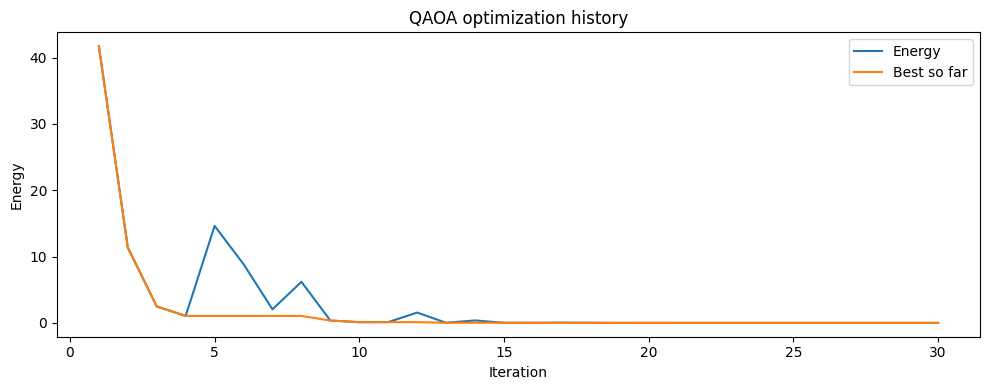

In [12]:
if len(history_df):
    plt.figure(figsize=(10, 4))
    plt.plot(history_df["iteration"], history_df["energy"], label="Energy")
    plt.plot(history_df["iteration"], history_df["best_energy"], label="Best so far")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.title("QAOA optimization history")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
classical_pool = classical_results.head(OVERVIEW_CLASSICAL_POOL).copy() if len(classical_results) else classical_results.copy()
qaoa_pool = samples_df.head(OVERVIEW_QAOA_POOL).copy() if len(samples_df) else samples_df.copy()

combined_frames = []
if len(classical_pool):
    combined_frames.append(classical_pool[candidate_cols])
if len(qaoa_pool):
    combined_frames.append(qaoa_pool[candidate_cols])

combined = pd.concat(combined_frames, ignore_index=True) if len(combined_frames) else pd.DataFrame(columns=candidate_cols)
combined = sort_candidates(combined).drop_duplicates(subset=["bitstring"], keep="first").reset_index(drop=True)

overview_df = sort_candidates(combined).head(TOP_N_EXPORT).copy()
overview_df.insert(0, "rank", range(1, len(overview_df) + 1))
display(overview_df)

,rank,bitstring,source,probability,qubo_value,return_term,risk_term,budget_term,exclusivity_term,qubo_reconstructed,...,avg_exclusivity_term_per_option,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,1,011111001000000000110000,qaoa_full_pennylane_p1,5.961104e-08,0.369463,-0.165655,0.535118,1.698107e-07,0.0,0.369463,...,0.0,1.000058e+06,58.277039,58.277039,8,5,0.971210,0.190707,4.882927,150032.823486
1,2,101111000100000000110000,qaoa_full_pennylane_p1,5.960847e-08,0.371442,-0.207359,0.578801,3.859101e-07,0.0,0.371442,...,0.0,9.999121e+05,-87.853302,87.853302,8,5,1.205813,0.198368,5.877034,150032.823486
2,3,001111100100000000110000,qaoa_full_pennylane_p1,5.960899e-08,0.384938,-0.214384,0.599323,8.114838e-08,0.0,0.384938,...,0.0,9.999597e+05,-40.286072,40.286072,8,5,1.245251,0.201844,5.971199,150032.823486
3,4,001111011000000000110000,qaoa_full_pennylane_p1,5.961016e-08,0.393408,-0.176146,0.569554,2.422575e-07,0.0,0.393408,...,0.0,9.999304e+05,-69.607117,69.607117,8,5,1.030309,0.196773,5.032746,150032.823486
4,5,001111000100000000110010,qaoa_full_pennylane_p1,5.960820e-08,0.395098,-0.221792,0.616873,1.596363e-05,0.0,0.395098,...,0.0,1.000565e+06,565.042206,565.042206,8,5,1.286141,0.204654,6.089007,150032.823486
5,6,011111000000001000110000,qaoa_full_pennylane_p1,5.961153e-08,0.396622,-0.120332,0.516953,8.117755e-07,0.0,0.396622,...,0.0,9.998726e+05,-127.418640,127.418640,8,5,0.716554,0.187477,3.608723,150032.823486
6,7,001111001000000000110001,qaoa_full_pennylane_p1,5.960972e-08,0.396821,-0.186775,0.583571,2.430646e-05,0.0,0.396821,...,0.0,9.993028e+05,-697.229675,697.229675,8,5,1.090722,0.199305,5.271937,150032.823486
7,8,001111000100000010110000,qaoa_full_pennylane_p1,5.960810e-08,0.399123,-0.236964,0.636088,1.069826e-07,0.0,0.399123,...,0.0,9.999537e+05,-46.256378,46.256378,8,5,1.372203,0.207944,6.406544,150032.823486
8,9,001111000100000000111000,qaoa_full_pennylane_p1,5.961130e-08,0.399245,-0.223438,0.622680,2.924763e-06,0.0,0.399245,...,0.0,9.997581e+05,-241.857941,241.857941,8,5,1.296405,0.205781,6.105541,150032.823486
9,10,011111000000000010110000,qaoa_full_pennylane_p1,5.960841e-08,0.399991,-0.111395,0.511386,2.118703e-07,0.0,0.399991,...,0.0,9.999349e+05,-65.095367,65.095367,8,5,0.666271,0.186453,3.358860,150032.823486


In [14]:
exploded_rows = []
for _, row in overview_df.iterrows():
    bitstring = row["bitstring"]
    source = row["source"]
    rank = int(row["rank"])
    bitvec = np.array(list(map(int, bitstring)), dtype=int)
    exploded_rows.extend(
        exploded_portfolio_rows(rank, source, bitstring, bitvec, blocks_df, Q, constant, qubo_meta, opt_tickers, opt_cost, opt_ret, Sigma_opt, risk_free, budget_usd)
    )

portfolios_df = pd.DataFrame(exploded_rows)
display(portfolios_df.head(40))

,rank,source,bitstring,Ticker,Company,Option Label,Shares,Approx Cost USD,Expected Return Proxy,Annual Volatility,...,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd,qubo_value
0,1,qaoa_full_pennylane_p1,011111001000000000110000,NVDA,NVIDIA,150k,756,149952.604614,0.954841,0.341148,...,1.000058e+06,58.277039,58.277039,8,5,0.971210,0.190707,4.882927,150032.823486,0.369463
1,1,qaoa_full_pennylane_p1,011111001000000000110000,AAPL,Apple,100k,380,100091.997681,0.343020,0.235278,...,1.000058e+06,58.277039,58.277039,8,5,0.971210,0.190707,4.882927,150032.823486,0.369463
2,1,qaoa_full_pennylane_p1,011111001000000000110000,AAPL,Apple,150k,569,149874.596527,0.343020,0.235278,...,1.000058e+06,58.277039,58.277039,8,5,0.971210,0.190707,4.882927,150032.823486,0.369463
3,1,qaoa_full_pennylane_p1,011111001000000000110000,MSFT,Microsoft,100k,238,100021.882324,0.151442,0.245407,...,1.000058e+06,58.277039,58.277039,8,5,0.971210,0.190707,4.882927,150032.823486,0.369463
4,1,qaoa_full_pennylane_p1,011111001000000000110000,MSFT,Microsoft,150k,357,150032.823486,0.151442,0.245407,...,1.000058e+06,58.277039,58.277039,8,5,0.971210,0.190707,4.882927,150032.823486,0.369463
5,1,qaoa_full_pennylane_p1,011111001000000000110000,MU,Micron Technology,100k,219,100133.372406,5.661693,0.590771,...,1.000058e+06,58.277039,58.277039,8,5,0.971210,0.190707,4.882927,150032.823486,0.369463
6,1,qaoa_full_pennylane_p1,011111001000000000110000,CSCO,Cisco,100k,1183,99963.500000,0.550304,0.253139,...,1.000058e+06,58.277039,58.277039,8,5,0.971210,0.190707,4.882927,150032.823486,0.369463
7,1,qaoa_full_pennylane_p1,011111001000000000110000,CSCO,Cisco,150k,1775,149987.500000,0.550304,0.253139,...,1.000058e+06,58.277039,58.277039,8,5,0.971210,0.190707,4.882927,150032.823486,0.369463
8,2,qaoa_full_pennylane_p1,101111000100000000110000,NVDA,NVIDIA,100k,504,99968.403076,0.954841,0.341148,...,9.999121e+05,-87.853302,87.853302,8,5,1.205813,0.198368,5.877034,150032.823486,0.371442
9,2,qaoa_full_pennylane_p1,101111000100000000110000,AAPL,Apple,100k,380,100091.997681,0.343020,0.235278,...,9.999121e+05,-87.853302,87.853302,8,5,1.205813,0.198368,5.877034,150032.823486,0.371442


In [15]:
solver_frames = []
if len(classical_results):
    best_classical = sort_candidates(classical_results).head(1).copy()
    solver_frames.append(best_classical.assign(solver="Classical Heuristic"))

if len(samples_df):
    best_qaoa = sort_candidates(samples_df).head(1).copy()
    solver_frames.append(best_qaoa.assign(solver=f"QAOA PennyLane p={QAOA_P} ({qaoa_mode})"))

solver_comparison_df = pd.concat(solver_frames, ignore_index=True) if len(solver_frames) else pd.DataFrame()
if len(solver_comparison_df):
    solver_comparison_df = solver_comparison_df[[
        "solver", "bitstring", "qubo_value",
        "return_term", "risk_term", "budget_term", "exclusivity_term", "qubo_reconstructed",
        "avg_return_term_per_option", "avg_risk_term_per_option", "avg_budget_term_per_option", "avg_exclusivity_term_per_option",
        "selected_usd", "budget_gap", "abs_budget_gap", "num_options", "num_distinct_assets",
        "portfolio_return", "portfolio_vol", "sharpe_like", "max_position_usd"
    ]]
display(solver_comparison_df)

,solver,bitstring,qubo_value,return_term,risk_term,budget_term,exclusivity_term,qubo_reconstructed,avg_return_term_per_option,avg_risk_term_per_option,...,avg_exclusivity_term_per_option,selected_usd,budget_gap,abs_budget_gap,num_options,num_distinct_assets,portfolio_return,portfolio_vol,sharpe_like,max_position_usd
0,Classical Heuristic,111111100000000000010000,0.477876,-0.096009,0.573885,1.470012e-07,0.0,0.477876,-0.012001,0.071736,...,0.0,9.999458e+05,-54.221985,54.221985,8,5,0.579764,0.197517,2.732750,150032.823486
1,QAOA PennyLane p=1 (exact_probs),011111001000000000110000,0.369463,-0.165655,0.535118,1.698107e-07,0.0,0.369463,-0.020707,0.066890,...,0.0,1.000058e+06,58.277039,58.277039,8,5,0.971210,0.190707,4.882927,150032.823486


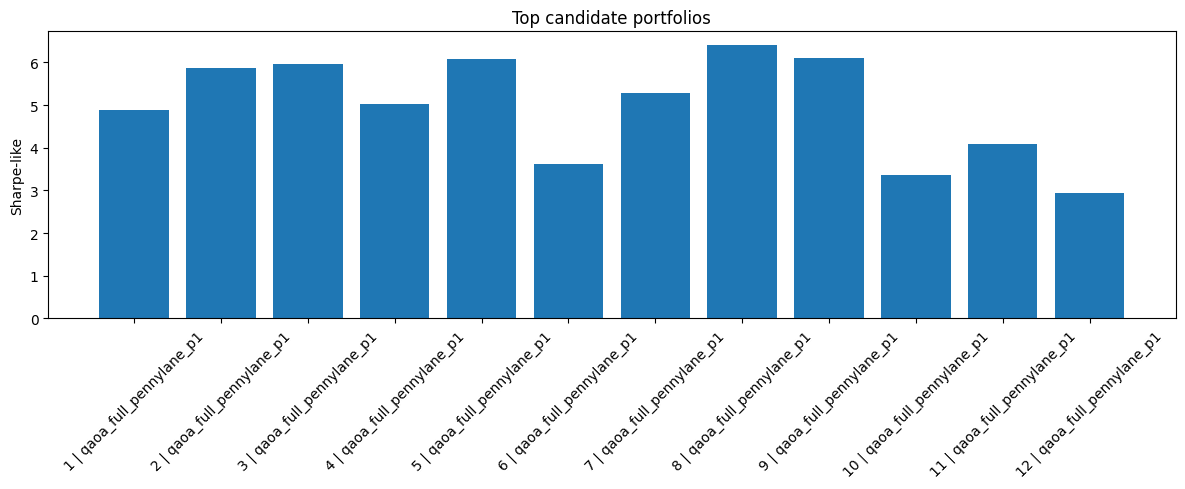

In [16]:
top_plot = overview_df.head(12).copy()
if len(top_plot):
    labels = top_plot["rank"].astype(str) + " | " + top_plot["source"].astype(str)

    plt.figure(figsize=(12, 5))
    plt.bar(labels, top_plot["sharpe_like"])
    plt.xticks(rotation=45)
    plt.ylabel("Sharpe-like")
    plt.title("Top candidate portfolios")
    plt.tight_layout()
    plt.show()

In [17]:
def write_df(ws, df, dark_fill, white_bold):
    for j, col in enumerate(df.columns, start=1):
        ws.cell(1, j, col)
        ws.cell(1, j).fill = dark_fill
        ws.cell(1, j).font = white_bold
    for i, row in enumerate(df.itertuples(index=False), start=2):
        for j, val in enumerate(row, start=1):
            ws.cell(i, j, val)

def write_results(xlsx_path, overview_df, portfolios_df, solver_comparison_df, classical_results, samples_df, history_df, best_gammas, best_betas, qaoa_p, qaoa_mode):
    wb = load_workbook(xlsx_path)

    for name in ["Results_Summary", "Results_Overview", "Results_Portfolios", "QAOA_Samples", "Classical_Candidates", "Solver_Comparison", "Optimization_History"]:
        if name in wb.sheetnames:
            wb.remove(wb[name])

    dark = PatternFill("solid", fgColor="1F4E78")
    white_bold = Font(color="FFFFFF", bold=True)

    summary_ws = wb.create_sheet("Results_Summary")
    summary_ws["A1"] = "Results summary"
    summary_ws["A1"].fill = dark
    summary_ws["A1"].font = white_bold

    summary_items = [
        ("Top-N exported", int(len(overview_df))),
        ("Classical candidate count", int(len(classical_results))),
        ("QAOA candidate count", int(len(samples_df))),
        ("QAOA enabled", int(ENABLE_QAOA)),
        ("QAOA p", int(qaoa_p)),
        ("QAOA mode", qaoa_mode),
        ("Decision variables", int(n)),
        ("Unique tickers", int(len(asset_universe))),
    ]
    summary_items += [(f"QAOA gamma_{i+1}", float(best_gammas[i]) if i < len(best_gammas) and np.isfinite(best_gammas[i]) else None) for i in range(qaoa_p)]
    summary_items += [(f"QAOA beta_{i+1}", float(best_betas[i]) if i < len(best_betas) and np.isfinite(best_betas[i]) else None) for i in range(qaoa_p)]
    summary_items += [
        ("Best overview Sharpe-like", float(overview_df["sharpe_like"].max()) if len(overview_df) else None),
        ("Best overview invested USD", float(overview_df.iloc[0]["selected_usd"]) if len(overview_df) else None),
        ("Best overview abs budget gap", float(overview_df.iloc[0]["abs_budget_gap"]) if len(overview_df) else None),
        ("Best overview return term", float(overview_df.iloc[0]["return_term"]) if len(overview_df) else None),
        ("Best overview risk term", float(overview_df.iloc[0]["risk_term"]) if len(overview_df) else None),
        ("Best overview budget term", float(overview_df.iloc[0]["budget_term"]) if len(overview_df) else None),
        ("Best overview exclusivity term", float(overview_df.iloc[0]["exclusivity_term"]) if len(overview_df) else None),
        ("Optimization iterations", int(len(history_df))),
    ]
    for i, (label, value) in enumerate(summary_items, start=2):
        summary_ws.cell(i, 1, label)
        summary_ws.cell(i, 2, value)

    overview_ws = wb.create_sheet("Results_Overview")
    write_df(overview_ws, overview_df, dark, white_bold)

    portfolios_ws = wb.create_sheet("Results_Portfolios")
    write_df(portfolios_ws, portfolios_df, dark, white_bold)

    qaoa_ws = wb.create_sheet("QAOA_Samples")
    write_df(qaoa_ws, samples_df.head(RESULT_CANDIDATE_LIMIT_PER_SOLVER), dark, white_bold)

    classical_ws = wb.create_sheet("Classical_Candidates")
    write_df(classical_ws, classical_results.head(RESULT_CANDIDATE_LIMIT_PER_SOLVER), dark, white_bold)

    solver_ws = wb.create_sheet("Solver_Comparison")
    write_df(solver_ws, solver_comparison_df, dark, white_bold)

    history_ws = wb.create_sheet("Optimization_History")
    write_df(history_ws, history_df, dark, white_bold)

    wb.save(xlsx_path)
    print(f"Results written to {xlsx_path.resolve()}")

write_results(
    xlsx_path=xlsx_path,
    overview_df=overview_df,
    portfolios_df=portfolios_df,
    solver_comparison_df=solver_comparison_df,
    classical_results=classical_results,
    samples_df=samples_df,
    history_df=history_df,
    best_gammas=best_gammas,
    best_betas=best_betas,
    qaoa_p=QAOA_P,
    qaoa_mode=qaoa_mode,
)

Results written to /Users/danielhug/code/qubit-lab/QAOA-Optimizer/Version 2/parametric_assets_only_input.xlsx
